# CE skewness vs cardinality (shared plotting)


In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
def _find_repo_root(start: Path) -> Path:
    markers = [
        Path("tasks/cardinality_estimation/ce_timeline_census"),
        Path("existing_benchmarks/AreCELearnedYet"),
    ]
    for candidate in [start] + list(start.parents):
        if all((candidate / m).exists() for m in markers):
            return candidate
    return start


REPO_ROOT_OVERRIDE = None  # e.g. "/Users/guanlil1/Dropbox/PostDoc/topics/WorkloadDatasetGenerator"
REPO_ROOT = (
    Path(REPO_ROOT_OVERRIDE).expanduser() if REPO_ROOT_OVERRIDE else _find_repo_root(Path.cwd())
)
print(f"CWD: {Path.cwd()}")
print(f"Using REPO_ROOT: {REPO_ROOT}")

RESULT_DIRS = [
    REPO_ROOT / "tasks/cardinality_estimation/ce_timeline_census/result/census13",
    REPO_ROOT / "existing_benchmarks/AreCELearnedYet/output/result/census13",
    REPO_ROOT / "existing_benchmarks/AreCELearnedYet/tasks/cardinality_estimation/ce_timeline_census/result/census13",
]
BASELINE_RESULT_DIR = RESULT_DIRS[0]
LOG_DIR = REPO_ROOT / "tasks/cardinality_estimation/ce_timeline_census/log/ce_timeline"
DATASET_TAG = "census"
BASE_VERSION = "original"
ESTIMATORS = ["postgres", "naru", "mscn"]
WORKLOAD_ALLOWLIST = None  # e.g. {"original_sqls_selectivity_1"}
INCLUDE_BASELINE = True  # include base version as t0
PRINT_BASELINE_PATHS = True
FALLBACK_VALUE = 0.0
USE_LOG_SCALE = True
MIN_ERROR = 1e-6
JITTER = 0.15
SCATTER_ALPHA = 0.15
SCATTER_SIZE = 6
FIGSIZE = (8, 4)
FONT_SIZE = 12
TITLE_SIZE = 13
TICK_SIZE = 10
plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": FONT_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "figure.titlesize": TITLE_SIZE,
})


CWD: /Users/guanlil1/Dropbox/PostDoc/topics/WorkloadDatasetGenerator/tasks/cardinality_estimation/ce_timeline_census/notebooks
Using REPO_ROOT: /Users/guanlil1/Dropbox/PostDoc/topics/WorkloadDatasetGenerator


In [3]:
def _parse_result_name(path: Path, dataset_tag: str):
    if path.suffix != ".csv":
        return None
    base = path.stem
    if "-version=" in base:
        base = base.split("-version=", 1)[0]
    marker = f"-{dataset_tag}_"
    if marker not in base:
        return None
    if "-" not in base:
        return None
    base, estimator = base.rsplit("-", 1)
    if estimator not in ESTIMATORS:
        return None
    version, workload = base.split(marker, 1)
    return version, workload, estimator


def _parse_log_name(path: Path, dataset_tag: str):
    if path.suffix != ".log":
        return None
    base = path.stem
    marker = f"_{dataset_tag}_"
    if marker not in base:
        return None
    version, rest = base.split(marker, 1)
    if "_" not in rest:
        return None
    workload, estimator = rest.rsplit("_", 1)
    if estimator not in ESTIMATORS:
        return None
    return version, workload, estimator


def _skew_value(version: str):
    if version == BASE_VERSION:
        return 0 if INCLUDE_BASELINE else None
    match = re.search(r"skew_(\d+)", version)
    if match:
        return int(match.group(1))
    return None


def _cardinality_step(version: str):
    if version == BASE_VERSION:
        return 0 if INCLUDE_BASELINE else None
    match = re.search(r"cardinality[_-]?t?(\d+)", version)
    if match:
        return int(match.group(1))
    return None


def _read_errors(path: Path):
    try:
        df = pd.read_csv(path)
    except Exception:
        return [FALLBACK_VALUE]
    if "error" not in df.columns:
        return [FALLBACK_VALUE]
    values = df["error"].dropna().tolist()
    return values if values else [FALLBACK_VALUE]


def _collect_results(case_name: str):
    entries = []
    for result_dir in RESULT_DIRS:
        if not result_dir.exists():
            continue
        for path in result_dir.glob("*.csv"):
            parsed = _parse_result_name(path, DATASET_TAG)
            if not parsed:
                continue
            version, workload, estimator = parsed
            if case_name == "skew":
                key_val = _skew_value(version)
            else:
                key_val = _cardinality_step(version)
            if key_val is None:
                continue
            if version == BASE_VERSION:
                expected = f"{BASE_VERSION}-{DATASET_TAG}_{workload}-{estimator}.csv"
                if path.parent != BASELINE_RESULT_DIR or path.name != expected:
                    continue
            entries.append({
                "version": version,
                "workload": workload,
                "estimator": estimator,
                "key": key_val,
                "path": path,
            })
    return entries


def _collect_expected_from_logs(case_name: str):
    expected = {}
    if not LOG_DIR.exists():
        return expected
    for path in LOG_DIR.glob("*.log"):
        parsed = _parse_log_name(path, DATASET_TAG)
        if not parsed:
            continue
        version, workload, estimator = parsed
        if case_name == "skew":
            key_val = _skew_value(version)
        else:
            key_val = _cardinality_step(version)
        if key_val is None:
            continue
        expected[(version, workload, estimator)] = key_val
    return expected


In [4]:
def _select_first(entries):
    priority = {str(d): i for i, d in enumerate(RESULT_DIRS)}
    entries.sort(key=lambda e: priority.get(str(e["path"].parent), 99))
    selected = {}
    for e in entries:
        key = (e["version"], e["workload"], e["estimator"])
        if key not in selected:
            selected[key] = e
    return selected


def _build_df(case_name: str):
    entries = _collect_results(case_name)
    expected = _collect_expected_from_logs(case_name)

    if not entries and not expected:
        print("No matches found for", case_name)
        for p in RESULT_DIRS:
            print(f"  RESULT_DIR: {p} (exists={p.exists()})")
        print(f"  LOG_DIR: {LOG_DIR} (exists={LOG_DIR.exists()})")
        raise RuntimeError("No results or logs found. Check paths.")

    selected = _select_first(entries)
    if PRINT_BASELINE_PATHS:
        baseline = [e for e in selected.values() if e["version"] == BASE_VERSION]
        if baseline:
            tag = "skew=0" if case_name == "skew" else "step 0"
            print(f"Baseline files ({case_name} {tag}):")
            for e in sorted(baseline, key=lambda r: (r["workload"], r["estimator"])):
                print(f"  {e['workload']} {e['estimator']}: {e['path']}")

    records = []
    for e in selected.values():
        records.append({
            "version": e["version"],
            "workload": e["workload"],
            "estimator": e["estimator"],
            "key": e["key"],
            "errors": _read_errors(e["path"]),
        })

    for (version, workload, estimator), key_val in expected.items():
        if (version, workload, estimator) in selected:
            continue
        records.append({
            "version": version,
            "workload": workload,
            "estimator": estimator,
            "key": key_val,
            "errors": [FALLBACK_VALUE],
        })

    df = pd.DataFrame(records)
    if WORKLOAD_ALLOWLIST:
        df = df[df["workload"].isin(WORKLOAD_ALLOWLIST)]
    return df


df_skew = _build_df("skew")
df_card = _build_df("cardinality")

workloads = sorted(set(df_skew["workload"].unique()) | set(df_card["workload"].unique()))
workloads
workloads = ['original_sqls_selectivity_2']

Baseline files (skew skew=0):
  original_normal_sqls postgres: /Users/guanlil1/Dropbox/PostDoc/topics/WorkloadDatasetGenerator/tasks/cardinality_estimation/ce_timeline_census/result/census13/original-census_original_normal_sqls-postgres.csv
  original_skew_sqls postgres: /Users/guanlil1/Dropbox/PostDoc/topics/WorkloadDatasetGenerator/tasks/cardinality_estimation/ce_timeline_census/result/census13/original-census_original_skew_sqls-postgres.csv
  original_sqls_selectivity_1 postgres: /Users/guanlil1/Dropbox/PostDoc/topics/WorkloadDatasetGenerator/tasks/cardinality_estimation/ce_timeline_census/result/census13/original-census_original_sqls_selectivity_1-postgres.csv
  original_sqls_selectivity_2 mscn: /Users/guanlil1/Dropbox/PostDoc/topics/WorkloadDatasetGenerator/tasks/cardinality_estimation/ce_timeline_census/result/census13/original-census_original_sqls_selectivity_2-mscn.csv
  original_sqls_selectivity_2 naru: /Users/guanlil1/Dropbox/PostDoc/topics/WorkloadDatasetGenerator/tasks/card

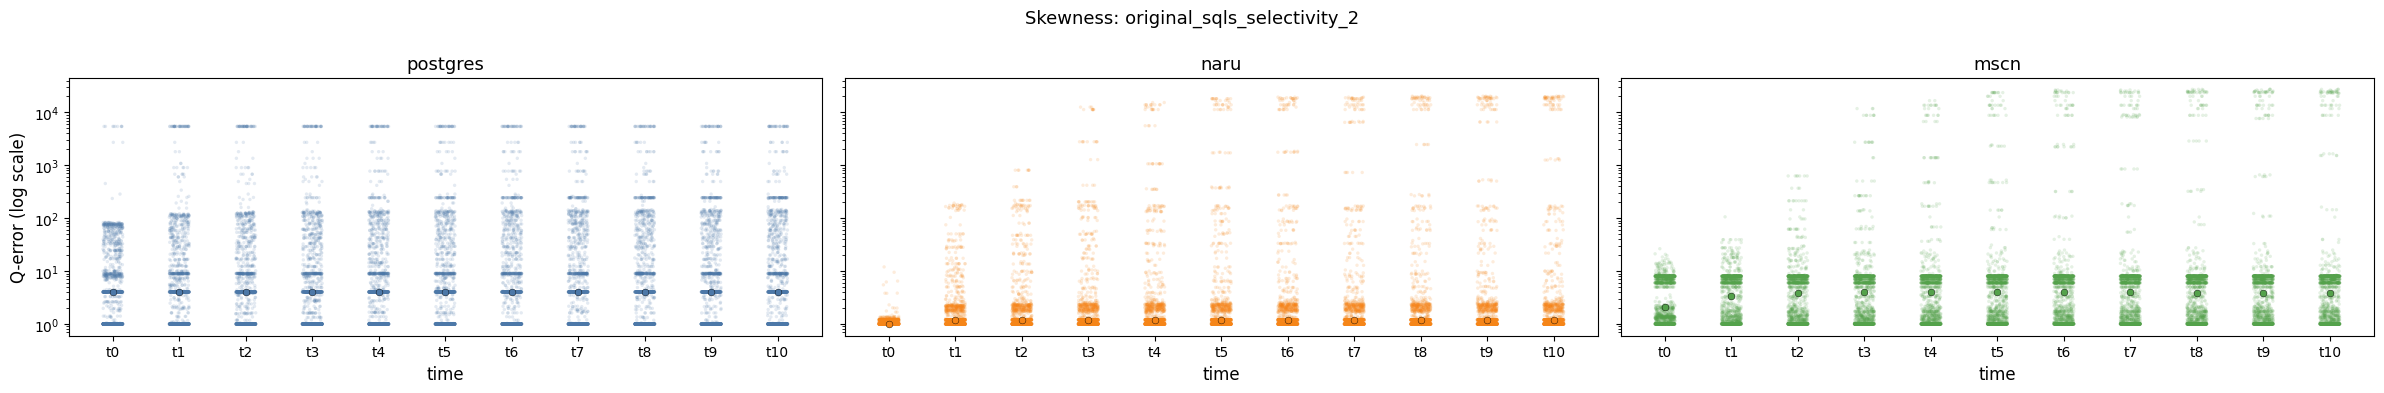

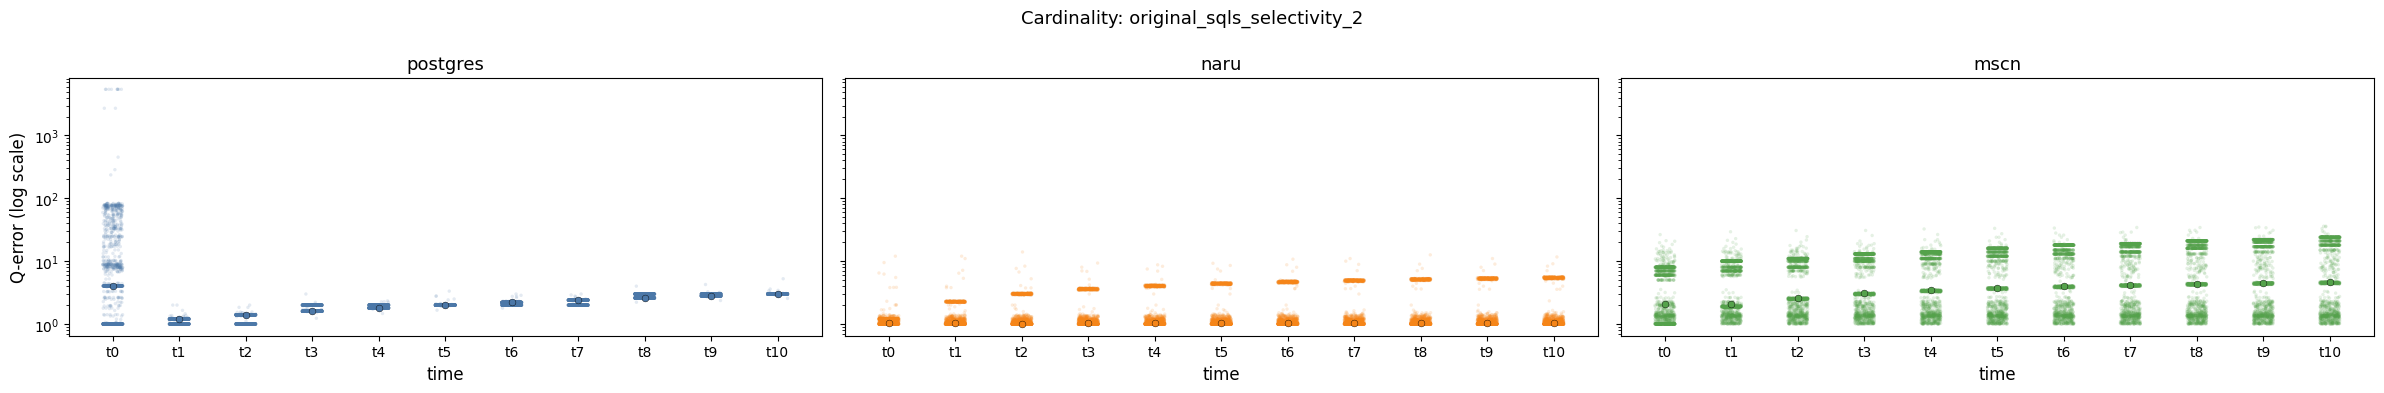

In [5]:
def _prep_values(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[~np.isnan(arr)]
    if USE_LOG_SCALE:
        arr = np.clip(arr, MIN_ERROR, None)
    return arr


def _build_workload_data(df, workload):
    sub = df[df["workload"] == workload]
    keys = sorted(sub["key"].unique())
    data = {k: {est: [FALLBACK_VALUE] for est in ESTIMATORS} for k in keys}
    for _, row in sub.iterrows():
        data[row["key"]][row["estimator"]] = row["errors"] or [FALLBACK_VALUE]
    return keys, data


def plot_case(df, workload, title_prefix):
    keys, data = _build_workload_data(df, workload)
    if not keys:
        return None
    labels = [f"t{i}" for i in range(len(keys))]

    colors = {
        "postgres": "#4C78A8",
        "naru": "#F58518",
        "mscn": "#54A24B",
    }

    n = len(ESTIMATORS)
    fig, axes = plt.subplots(1, n, figsize=(FIGSIZE[0] * n, FIGSIZE[1]), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, est in zip(axes, ESTIMATORS):
        for i, key in enumerate(keys):
            values = _prep_values(data[key].get(est, [FALLBACK_VALUE]))
            if values.size == 0:
                continue
            jitter = np.random.uniform(-JITTER, JITTER, size=values.size)
            x = np.full(values.size, i) + jitter
            ax.scatter(
                x,
                values,
                s=SCATTER_SIZE,
                alpha=SCATTER_ALPHA,
                color=colors[est],
                edgecolors="none",
            )
            median = float(np.median(values)) if values.size else np.nan
            ax.scatter(
                [i],
                [median],
                s=24,
                color=colors[est],
                edgecolors="black",
                linewidths=0.3,
            )

        ax.set_title(est)
        ax.set_xticks(range(len(keys)))
        ax.set_xticklabels(labels)
        ax.set_xlabel("time")

    axes[0].set_ylabel("Q-error" + (" (log scale)" if USE_LOG_SCALE else ""))
    if USE_LOG_SCALE:
        axes[0].set_yscale("log")
    fig.suptitle(f"{title_prefix}: {workload}")
    fig.tight_layout()
    return fig


for workload in workloads:
    plot_case(df_skew, workload, "Skewness")
    plot_case(df_card, workload, "Cardinality")
